In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.io.fits as fitsio
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.Util import util
import lenstronomy.Util.param_util as param_util
import sys
from lenstronomy.LensModel.Solver.lens_equation_solver import LensEquationSolver
sys.path.append('/huawei/osv1/linshijie_BNU/code/lib')
import cfuncs as cf
from astropy.cosmology import Planck15,FlatLambdaCDM,z_at_value
from astropy.table import Table
import astropy.units as u

/huawei/osv1/linshijie_BNU/anaconda3/envs/WL/lib/python3.11/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)


In [2]:
def calc_lensingMaps(hdu_ini,hdu_fin):
    hdu = fitsio.open(hdu_ini)
    raysImg= hdu[1].data
    hdu.close()
    hdu = fitsio.open(hdu_fin)
    raysSrc= hdu[1].data
    nc_ray = hdu[1].header['nc_ray']
    hdu.close()
    
    daf1 = -np.reshape(raysSrc['x1'] - raysImg['x1'], [nc_ray, nc_ray])
    daf2 = -np.reshape(raysSrc['x2'] - raysImg['x2'], [nc_ray, nc_ray])
    daf1 = np.rad2deg(daf1)*3600 ###转成角秒
    daf2 = np.rad2deg(daf2)*3600

    A0 = raysSrc['A0']
    A1 = raysSrc['A1']
    A2 = raysSrc['A2']
    A3 = raysSrc['A3']
    # plt.figure()
    # plt.imshow(np.reshape(A0,[nnn,nnn]))
    # plt.colorbar()
    kap = 1.0-0.5*(A0 + A3)
    sh1 =    -0.5*(A0 - A3)
    sh2 =    -0.5*(A1 + A2)
    mua = 1.0/(A0*A3 - A1*A2)
    kap = np.reshape(kap, [nc_ray, nc_ray])
    mua = np.reshape(mua, [nc_ray, nc_ray])
    sh1 = np.reshape(sh1, [nc_ray, nc_ray])
    sh2 = np.reshape(sh2, [nc_ray, nc_ray])
    
    lensingMaps = {}
    lensingMaps['mua'] = mua
    lensingMaps['kappa'] = kap
    lensingMaps['gamma1']= sh1
    lensingMaps['gamma2']= sh2
    lensingMaps['alpha1']= daf1
    lensingMaps['alpha2']= daf2
    lensingMaps['A0'] = np.reshape(A0,[nc_ray, nc_ray])
    lensingMaps['A1'] = np.reshape(A1,[nc_ray, nc_ray])
    lensingMaps['A2'] = np.reshape(A2,[nc_ray, nc_ray])
    lensingMaps['A3'] = np.reshape(A3,[nc_ray, nc_ray])
    lensingMaps['xf1']    = np.reshape(np.rad2deg(raysImg['x1']),[nc_ray, nc_ray]) # degree
    lensingMaps['xf2']    = np.reshape(np.rad2deg(raysImg['x2']),[nc_ray, nc_ray])
    lensingMaps['yf1']    = np.reshape(np.rad2deg(raysSrc['x1']),[nc_ray, nc_ray]) # degree
    lensingMaps['yf2']    = np.reshape(np.rad2deg(raysSrc['x2']),[nc_ray, nc_ray])
    return lensingMaps
# 定义一个函数来读取参数并返回它们作为字典
def read_parameters(file_path):
    params = {}
    with open(file_path, 'r') as file:
        for line in file:
            # 移除行尾的换行符并分割键和值
            line = line.strip()
            if line:  # 确保行不为空
                key, value_with_unit = line.split(' = ')  # 分割并去除等号两边的空格
                key = key.strip()  # 移除键的首尾空格
                value_with_unit = value_with_unit.strip()  # 移除值和单位的首尾空格
                
                # 提取值部分，并去除单位
                value = value_with_unit.split()[0]  # 分割并取值的部分
                
                # 将值转换为适当的数据类型
                if value.isdigit():  # 如果值是整数
                    params[key] = int(value)
                else:
                    # 假设值是浮点数
                    try:
                        params[key] = float(value)  # 尝试转换为float
                    except ValueError:
                        params[key] = value  # 如果转换失败，保持原样    
    return params
def Dc(z):                      # Mpc/h
    res = cosmo.comoving_distance(z).value*cosmo.h
    return res
def Dc2redshift(Dc):            # Mpc/h
    return z_at_value(cosmo.comoving_distance,Dc/cosmo.h*u.Mpc).value

In [3]:
case = 199
hdu_ini_los = '/huawei/osv1/linshijie_BNU/PAPER1/data/image_rays/case{:04}'.format(case)+'/wtml/testrays0000.fits'
hdu_fin_los = '/huawei/osv1/linshijie_BNU/PAPER1/data/image_rays/case{:04}'.format(case)+'/wtml/testrays0076.fits'

# read the case.txt file
case_file = '/huawei/osv1/linshijie_BNU/PAPER1/data/image_rays/case{:04}'.format(case)+'/Case.txt'
with open(case_file) as f:
    lines = f.readlines()
    for line in lines:
        if line.startswith('mlcase'):
            mlcase = int(line.split('=')[1])
        if line.startswith('highDens'):
            highdencase = int(line.split('=')[1])
f.close()

# highden_file = '/huawei/osv1/linshijie_BNU/PAPER1/data/high_dens/case{:04}'.format(highdencase)+'/center_position.txt'
# with open(highden_file) as f:
#     lines = f.readlines()
#     for line in lines:
#         if line.startswith('num_lensplane'):
#             num_lensplane = int(line.split('=')[1])
num_lensplane = 38            

hdu_fin_tolens = '/huawei/osv1/linshijie_BNU/PAPER1/data/image_rays/case{:04}'.format(case)+'/all/testrays{:04}'.format(num_lensplane)+'.fits'

hdu_ini_lens = '/huawei/osv1/linshijie_BNU/PAPER1/data/image_rays/case{:04}'.format(case)+'/oml/testrays0000.fits'
hdu_fin_lens = '/huawei/osv1/linshijie_BNU/PAPER1/data/image_rays/case{:04}'.format(case)+'/oml/testrays0001.fits'

hdu_ini_all = '/huawei/osv1/linshijie_BNU/PAPER1/data/image_rays/case{:04}'.format(case)+'/all/testrays0000.fits'
hdu_fin_all = '/huawei/osv1/linshijie_BNU/PAPER1/data/image_rays/case{:04}'.format(case)+'/all/testrays0076.fits'

dataMY_los    = calc_lensingMaps(hdu_ini_los,hdu_fin_los)
dataMY_lens   = calc_lensingMaps(hdu_ini_lens,hdu_fin_lens)
dataMY_all    = calc_lensingMaps(hdu_ini_all,hdu_fin_all)
dataMY_tolens = calc_lensingMaps(hdu_ini_lens,hdu_fin_tolens)

In [4]:
## 1 arcmin
# xmin = np.min(dataMY_all['xf1'][0,:])
# xmax = np.max(dataMY_all['xf1'][0,:])
# ymin = np.min(dataMY_all['xf2'][:,0])
# ymax = np.max(dataMY_all['xf2'][:,0])

xmin = np.min(dataMY_all['xf1'][:,0])
xmax = np.max(dataMY_all['xf1'][:,0])
ymin = np.min(dataMY_all['xf2'][0,:])
ymax = np.max(dataMY_all['xf2'][0,:])

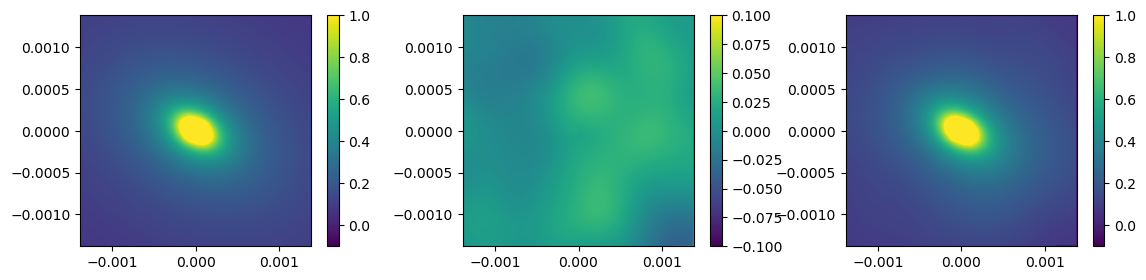

In [5]:
fig_kappa, ax_kappa = plt.subplots(1,3,figsize=[14,3])
kappa_lens = ax_kappa[0].imshow(dataMY_lens['kappa'].T, vmin=-0.1, vmax=1,extent=(xmin,xmax,ymin,ymax),origin='lower')
kappa_los = ax_kappa[1].imshow(dataMY_los['kappa'].T, vmin=-0.1, vmax=0.1,extent=(xmin,xmax,ymin,ymax),origin='lower')
kappa_all = ax_kappa[2].imshow(dataMY_all['kappa'].T, vmin=-0.1, vmax=1,extent=(xmin,xmax,ymin,ymax),origin='lower')

fig_kappa.colorbar(kappa_lens)
fig_kappa.colorbar(kappa_los)
fig_kappa.colorbar(kappa_all)

In [6]:
## find which ray will trace to the center of the plane
mid = int(len(dataMY_lens['kappa'])/2)
center_ra,center_dec = dataMY_lens['xf1'][mid,0],\
    dataMY_lens['xf2'][0,mid]
print('the center of the rays plane:',center_ra*3600,center_dec*3600,'arcsec')
distances=(dataMY_tolens['yf1']-center_ra)**2+(dataMY_tolens['yf2']-center_dec)**2
ID_ra_tolens,ID_dec_tolens = np.unravel_index(distances.argmin(), distances.shape)
print('the ID of the center ray :', ID_ra_tolens, ID_dec_tolens)
print('and this ray will go to:',dataMY_all['yf1'][ID_ra_tolens, ID_dec_tolens]*3600,dataMY_all['yf2'][ID_ra_tolens, ID_dec_tolens]*3600)

the center of the rays plane: 0.025000000000000005 0.025000000000000005 arcsec
the ID of the center ray : 100 100
and this ray will go to: -0.8078266673841945 -0.9920591489985917


In [7]:
## find the average alpha to the lens around the center ray (10 aresecs)
alpha1_tolens = dataMY_tolens['alpha1']
alpha2_tolens = dataMY_tolens['alpha2']
print('the average alpha to the lens around the center ray:',np.mean(alpha1_tolens),np.mean(alpha2_tolens),'arcsec')

the average alpha to the lens around the center ray: 0.004666834114014979 0.004383470869359546 arcsec


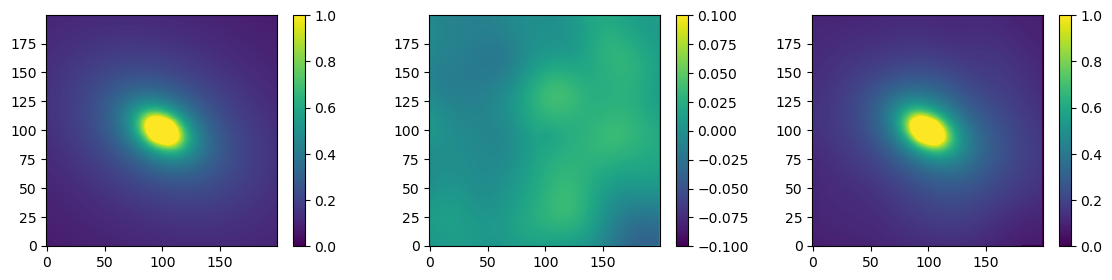

In [8]:
# ID_ra_tolens,ID_dec_tolens = 616,601
kappa_los_center = dataMY_los['kappa'].T
kappa_all_center = dataMY_all['kappa'].T
kappa_lens_center = dataMY_lens['kappa'].T
################## PLOT ##################
fig_kappa, ax_kappa = plt.subplots(1,3,figsize=[14,3])
kappa_lens = ax_kappa[0].imshow(kappa_lens_center,\
                                   vmin=0, vmax=1,origin='lower')
kappa_los = ax_kappa[1].imshow(kappa_los_center,\
                                  vmin=-0.1, vmax=0.1,origin='lower')
kappa_all = ax_kappa[2].imshow(kappa_all_center,\
                                  vmin=0, vmax=1,origin='lower')

fig_kappa.colorbar(kappa_lens,ax=ax_kappa[0])
fig_kappa.colorbar(kappa_los,ax=ax_kappa[1])
fig_kappa.colorbar(kappa_all,ax=ax_kappa[2])
# fig_kappa.savefig('/huawei/osv1/linshijie_BNU/simu_data/image_rays/case{:04}'.format(case)+'/kappa_center.png')

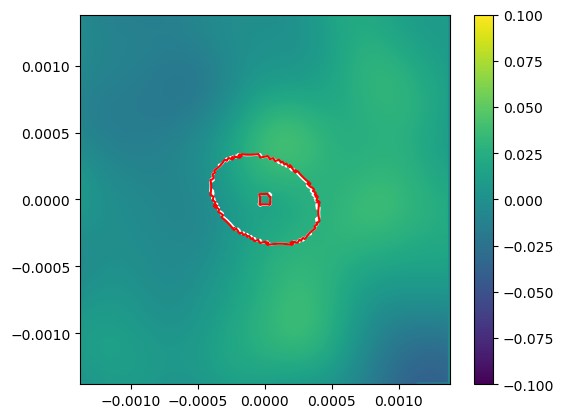

In [9]:
x_center = dataMY_all['xf2']
y_center = dataMY_all['xf1']
xmin_center = np.min(x_center[0,:])
xmax_center = np.max(x_center[0,:])
ymin_center = np.min(y_center[:,0])
ymax_center = np.max(y_center[:,0])

mua_los_center = dataMY_los['mua'].T
mua_all_center = dataMY_all['mua'].T
mua_lens_center = dataMY_lens['mua'].T

plt.imshow(kappa_los_center,vmin=-0.1, vmax=+0.1,extent = (xmin_center,xmax_center,ymin_center,ymax_center),origin='lower')
plt.colorbar()
plt.contour(x_center,y_center,mua_lens_center,colors=('w',))
plt.contour(x_center,y_center,mua_all_center,colors=('r',))
# plt.savefig('/huawei/osv1/linshijie_BNU/simu_data/image_rays/case{:04}'.format(case)+'/wl.png')

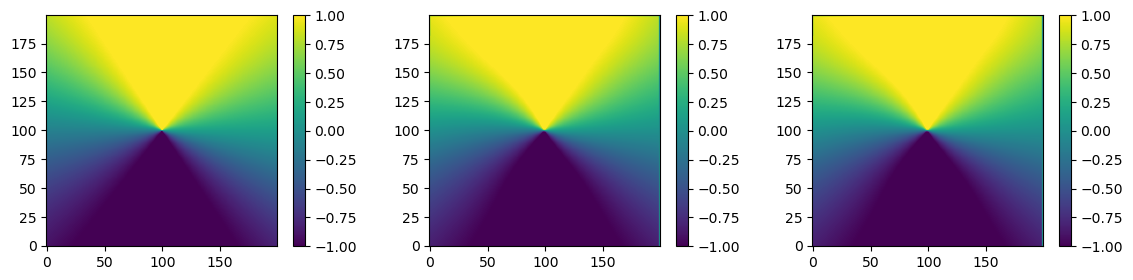

In [10]:
alpha1_los_center = dataMY_los['alpha1']
alpha1_all_center = dataMY_all['alpha1']
alpha1_lens_center = dataMY_lens['alpha1']


################## PLOT ##################
fig_alpha1, ax_alpha1 = plt.subplots(1,3,figsize=[14,3])
alpha1_lens = ax_alpha1[0].imshow(alpha1_lens_center,\
                                   vmin=-1, vmax=1,origin='lower')
alpha1_los = ax_alpha1[1].imshow(alpha1_los_center-np.mean(alpha1_los_center),\
                                  vmin=-1, vmax=1,origin='lower')
alpha1_all = ax_alpha1[2].imshow(alpha1_all_center-np.mean(alpha1_all_center),\
                                  vmin=-1, vmax=1,origin='lower')

fig_alpha1.colorbar(alpha1_lens,ax=ax_alpha1[0])
fig_alpha1.colorbar(alpha1_los,ax=ax_alpha1[1])
fig_alpha1.colorbar(alpha1_all,ax=ax_alpha1[2])

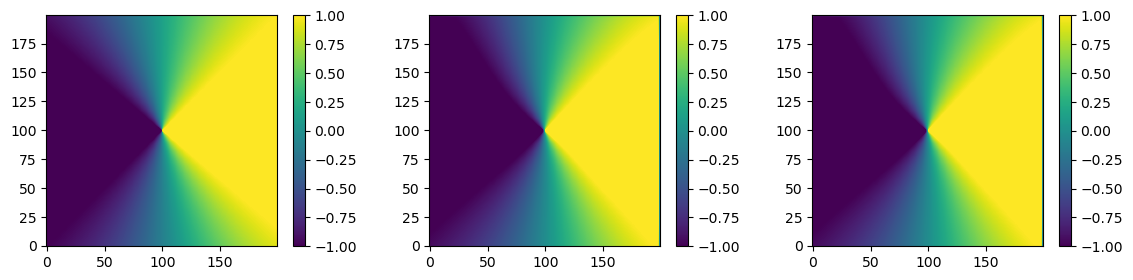

In [11]:
alpha2_los_center = dataMY_los['alpha2']
alpha2_all_center = dataMY_all['alpha2']
alpha2_lens_center = dataMY_lens['alpha2']

################## PLOT ##################
fig_alpha2, ax_alpha2 = plt.subplots(1,3,figsize=[14,3])
alpha2_lens = ax_alpha2[0].imshow(alpha2_lens_center,\
                                   vmin=-1, vmax=1,origin='lower')
alpha2_los = ax_alpha2[1].imshow(alpha2_los_center-np.mean(alpha2_los_center),\
                                  vmin=-1, vmax=1,origin='lower')
alpha2_all = ax_alpha2[2].imshow(alpha2_all_center-np.mean(alpha2_all_center),\
                                  vmin=-1, vmax=1,origin='lower')

fig_alpha2.colorbar(alpha2_lens,ax=ax_alpha2[0])
fig_alpha2.colorbar(alpha2_los,ax=ax_alpha2[1])
fig_alpha2.colorbar(alpha2_all,ax=ax_alpha2[2])

In [12]:
print('the average alpha to the source around the center ray:',np.mean(alpha1_los_center),np.mean(alpha2_los_center))

the average alpha to the source around the center ray: 0.022688215751187363 -0.01093363945883113


In [13]:
# center_ra,center_dec = (dataMY_lens['xf1'][mid,0]+dataMY_lens['xf1'][mid+1,0])/2,\
#     (dataMY_lens['xf2'][0,mid]+dataMY_lens['xf2'][0,mid])/2
center_ra,center_dec = dataMY_lens['xf1'][mid,0],\
    dataMY_lens['xf2'][0,mid]
l_x = dataMY_lens['xf2']
l_y = dataMY_lens['xf1']

In [14]:
mainlens_file = '/huawei/osv1/linshijie_BNU/simu_data/mainlens/case{:04}'.format(mlcase)+'/parameters.txt'
mainlens_params = read_parameters(mainlens_file)

theta_e = 1.7
phi_q,q = (mainlens_params['phi'])/180*np.pi,mainlens_params['q']

e1, e2 = param_util.phi_q2_ellipticity(phi_q, q)
# lensing quantities
lens_model_list = ['SIE']
kwargs_spemd = {'theta_E': theta_e, 'center_x': 0, 'center_y': 0, 'e1': e1, 'e2': e2}  # parameters of the deflector lens model
# kwargs_shear = {'gamma1': 0.0, 'gamma2': -0.05}  # shear values to the source plane

kwargs_lens = [kwargs_spemd]
lens_model_class = LensModel(lens_model_list)

numPix = len(l_x) # number of pixels per axis of the image to model
pixel_scale = 0.05  # angular scale of a pixel [arcsec]
# generate the coordinate grid and image properties (we only read out the relevant lines we need)
ra_grid, dec_grid, ra_at_xy_0, dec_at_xy_0, _, _, Mpix2coord, _ = util.make_grid_with_coordtransform(
    numPix=numPix, deltapix=pixel_scale, center_ra=0, center_dec=0, subgrid_res=1, inverse=False)
alpha1_lenstro,alpha2_lenstro = lens_model_class.alpha(ra_grid, dec_grid, kwargs_lens)

ra_grid, dec_grid = np.reshape(ra_grid, [numPix, numPix]), np.reshape(dec_grid, [numPix, numPix])
alpha1_lenstro = np.reshape(alpha1_lenstro, [numPix, numPix])
alpha2_lenstro = np.reshape(alpha2_lenstro, [numPix, numPix])


In [15]:
theta_e = 1.7*(alpha1_lens_center[0,0])/alpha1_lenstro[0,0]
print('theta_e:',theta_e)
print('phi:',phi_q,'q:',q)
# phi_q,q = (270-mainlens_params['phi'])/180*np.pi,mainlens_params['q']
# e1, e2 = param_util.phi_q2_ellipticity(phi_q, q)
# lensing quantities
lens_model_list = ['SIE']
kwargs_spemd = {'theta_E': theta_e, 'center_x': 0, 'center_y': 0, 'e1': e1, 'e2': e2}  # parameters of the deflector lens model
# kwargs_shear = {'gamma1': 0.0, 'gamma2': -0.05}  # shear values to the source plane

kwargs_lens = [kwargs_spemd]
lens_model_class = LensModel(lens_model_list)

alpha1_lenstro,alpha2_lenstro = lens_model_class.alpha(ra_grid, dec_grid, kwargs_lens)

ra_grid, dec_grid = np.reshape(ra_grid, [numPix, numPix]), np.reshape(dec_grid, [numPix, numPix])
alpha1_lenstro = np.reshape(alpha1_lenstro, [numPix, numPix])
alpha2_lenstro = np.reshape(alpha2_lenstro, [numPix, numPix])

theta_e: 1.2901967641411005
phi: 2.6179938779914944 q: 0.7000000000000001


In [16]:
s_x_lenstro = (l_x-center_dec)*3600+0.025 - alpha1_lenstro
s_y_lenstro = (l_y-center_ra)*3600+0.025 - alpha2_lenstro

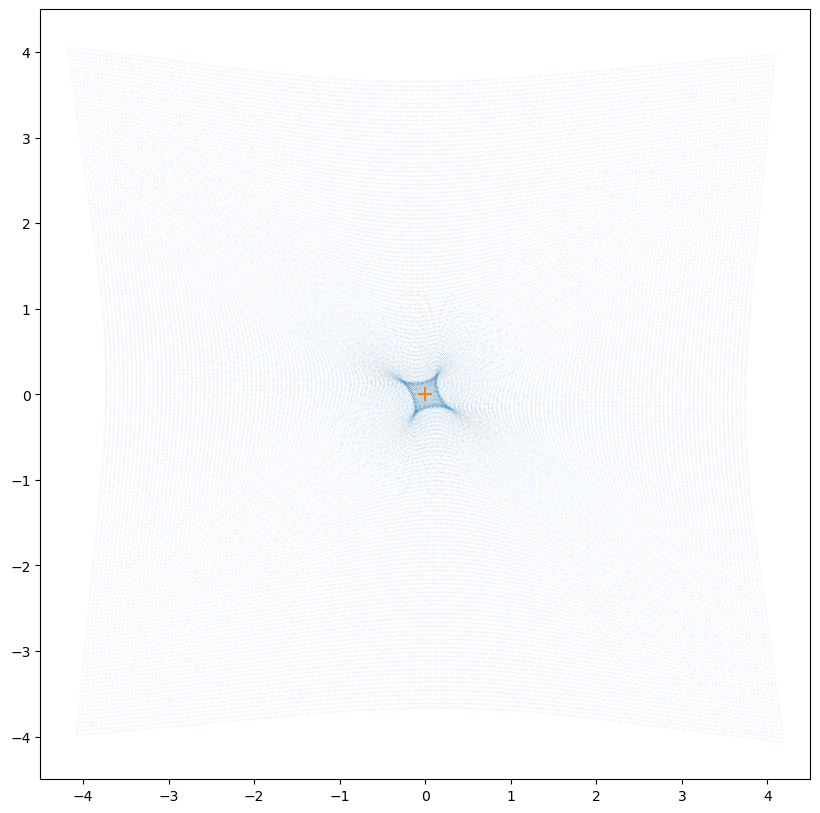

In [17]:
plt.figure(figsize=(10,10))
plt.scatter(s_x_lenstro, s_y_lenstro,s=0.01, marker='.')
plt.scatter(0,0,s=100,marker='+')
plt.xlim(-4.5,4.5)
plt.ylim(-4.5,4.5)
plt.gca().set_aspect("equal")

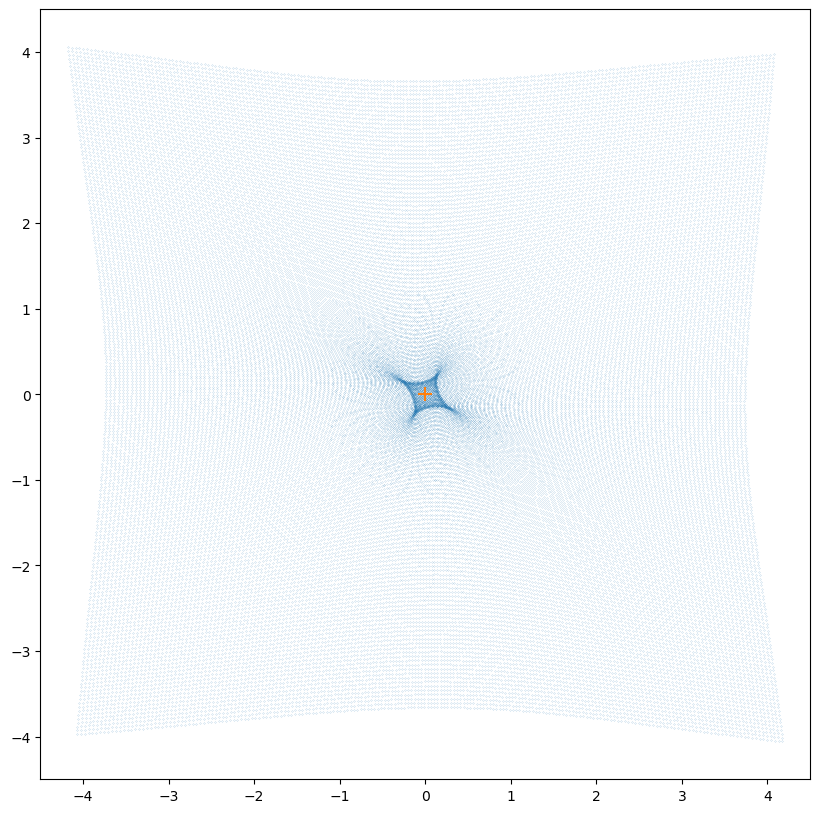

In [18]:
plt.figure(figsize=(10,10))
s_x = (dataMY_lens['yf2'])*3600
s_y = (dataMY_lens['yf1'])*3600
plt.scatter(s_y[:, :], s_x[:, :],s=0.01, marker='o')
plt.scatter(0.0,0.0,s=100,marker='+')
plt.xlim(-4.5,4.5)
plt.ylim(-4.5,4.5)
plt.gca().set_aspect("equal")

In [19]:
kappa_lens_center = dataMY_lens['kappa'].T
l_y_lens_center   = (dataMY_lens['xf2']-center_ra)*3600+0.025
l_x_lens_center   = (dataMY_lens['xf1']-center_dec)*3600+0.025
s_y_lens_center   = (dataMY_lens['yf2']-center_ra)*3600+0.025
s_x_lens_center   = (dataMY_lens['yf1']-center_dec)*3600+0.025
mua_lens_center   = dataMY_lens['mua'].T

In [20]:
xmin_center = np.min(l_x_lens_center[:,0])
xmax_center = np.max(l_x_lens_center[:,0])
ymin_center = np.min(l_y_lens_center[0,:])
ymax_center = np.max(l_y_lens_center[0,:])
print(xmin_center,xmax_center,ymin_center,ymax_center)

-4.975 4.9750000000000005 -4.975 4.9750000000000005


In [66]:
ra_degree = center_ra; dec_degree = center_dec

source_x = np.random.uniform(-0.15,0.15); source_y = np.random.uniform(-0.15,0.15)
# ra_arcsec, dec_arcsec = ra_degree*3600 ,dec_degree*3600

# import the LightModel class #
from lenstronomy.LightModel.light_model import LightModel

## source light model
source_light_model_list = ['SERSIC_ELLIPSE']
lightModel_source = LightModel(light_model_list=source_light_model_list)
# define the parameters #
kwargs_light_source = [{'amp': 4000, 'R_sersic': 0.1, 'n_sersic': 1, 'e1': -0.1, 'e2': 0.1, 'center_x': source_x, 'center_y':source_y }]

## lens light model
kwargs_sersic_lens = {'amp': 40, 'R_sersic': 0.6, 'n_sersic': 2, 'e1': -0.1, 'e2': 0.1, 'center_x': 0, 'center_y':0 }
lens_light_model_list = ['SERSIC_ELLIPSE']
kwargs_lens_light = [kwargs_sersic_lens]
lens_light_model_class = LightModel(lens_light_model_list)

In [67]:
# evaluate surface brightness at a specific position #
flux_source_singlens = lightModel_source.surface_brightness(x=s_x_lens_center, y=s_y_lens_center, kwargs_list=kwargs_light_source).T

# evaluate surface brightness at a specific position #
flux_lens = lens_light_model_class.surface_brightness(x=l_x_lens_center, y=l_y_lens_center, kwargs_list=kwargs_lens_light)

# evaluate surface brightness at a specific position #
flux_source_lenstro = lightModel_source.surface_brightness(x=s_x_lenstro, y=s_y_lenstro, kwargs_list=kwargs_light_source)


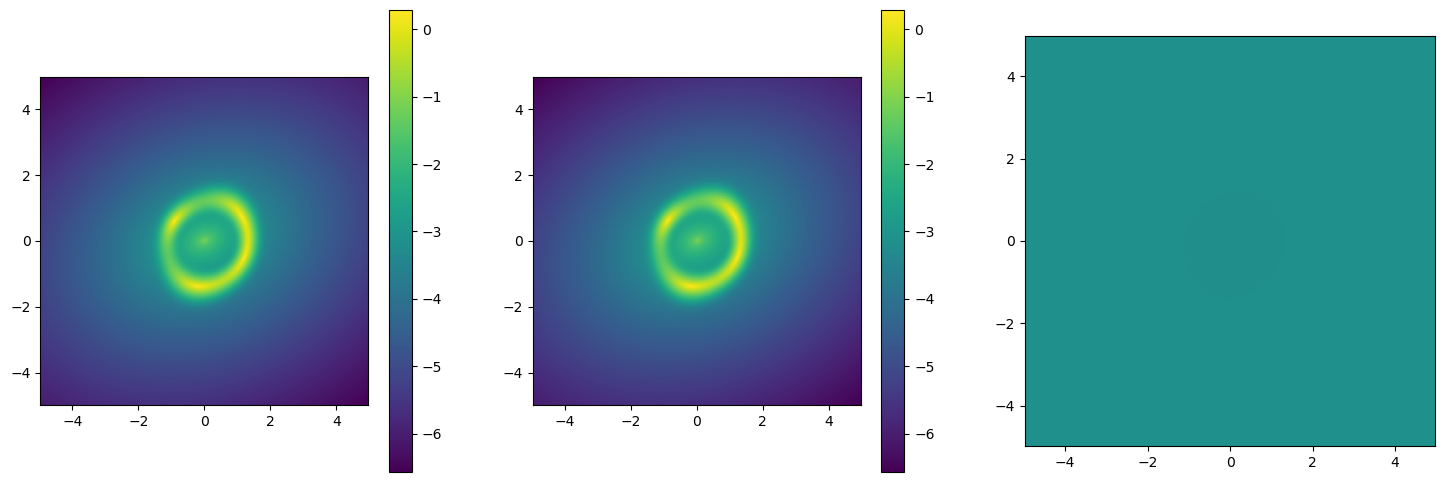

In [68]:
fig,ax = plt.subplots(1,3,figsize=(18,6))
ax_raytr = ax[0].imshow(np.log10(flux_lens+flux_source_singlens)-4,origin='lower',extent=(xmin_center,xmax_center,ymin_center,ymax_center))
ax_lenstro = ax[1].imshow(np.log10(flux_lens+flux_source_lenstro)-4,origin='lower',extent=(xmin_center,xmax_center,ymin_center,ymax_center))
ax_res = ax[2].imshow(flux_source_singlens/10000-flux_source_lenstro/10000,origin='lower',extent=(xmin_center,xmax_center,ymin_center,ymax_center),vmin =-0.0001,vmax=0.0001)
fig.colorbar(ax_raytr,ax=ax[0])
fig.colorbar(ax_lenstro,ax=ax[1])

In [69]:
# write a txt file to save the paremeter of the lens model
print(theta_e)
lens_model_file = '/huawei/osv1/linshijie_BNU/PAPER1/data/image_rays/case{:04}'.format(case)+'/LensingParameters.txt'
with open(lens_model_file,'w') as f:
    f.write('theta_E = {:f}\n'.format(theta_e))
    f.write('phi = {:f}\n'.format(phi_q))
    f.write('q = {:f}\n'.format(q))
    f.write('source_x = {:f}\n'.format(source_x))
    f.write('source_y = {:f}\n'.format(source_y))

1.2901967641411005


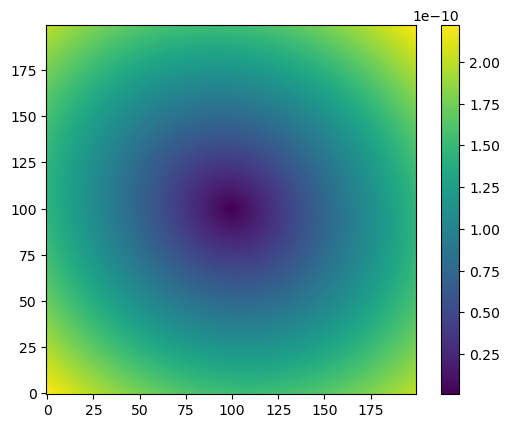

In [70]:
phi = lens_model_class.potential(ra_grid, dec_grid, kwargs_lens)
plt.imshow(phi*(np.pi/180/3600)**2,origin='lower')
plt.colorbar()
np.savez('/huawei/osv1/linshijie_BNU/PAPER1/data/image_rays/case{:04}'.format(case)+'/potential_sl.npz',phi=phi*(np.pi/180/3600)**2)

In [71]:
xroot1_tmp_arcsec, xroot2_tmp_arcsec = \
                    cf.call_mapping_triangles([source_x, source_y],\
                                               l_x_lens_center,l_y_lens_center, \
                                               s_x_lens_center,s_y_lens_center)

In [72]:
# xroot1_tmp_arcsec, xroot2_tmp_arcsec

# keep 3 digits
xroot1_tmp_arcsec = np.round(xroot1_tmp_arcsec,3)
xroot2_tmp_arcsec = np.round(xroot2_tmp_arcsec,3)

mua_lens_center   = dataMY_lens['mua'].T

sourceID_x = np.round(xroot1_tmp_arcsec/0.05).astype(int)+int(numPix/2)
sourceID_y = np.round(xroot2_tmp_arcsec/0.05).astype(int)+int(numPix/2)

print(sourceID_x,sourceID_y)

[124  82  96 100 123] [ 90 112  72 100 115]


In [73]:
mua_image_rayt = mua_lens_center[sourceID_y,sourceID_x]
print(xroot1_tmp_arcsec, xroot2_tmp_arcsec)
print(mua_image_rayt)

[ 1.211 -0.906 -0.203 -0.003  1.133] [-0.51   0.599 -1.388  0.002  0.739]
[-6.35661854e+00 -2.34789255e+00  5.23150606e+00  5.73030427e-03
  5.27990286e+00]


In [74]:
lensEquationSolver = LensEquationSolver(lens_model_class)
x_image, y_image = lensEquationSolver.findBrightImage(source_x, source_y, kwargs_lens,
                                                      min_distance=0.05, search_window=numPix * 0.05)

# keep 4 digits
x_image = np.round(x_image,3)
y_image = np.round(y_image,3)
print(x_image, y_image)
# compute lensing magnification at image positions
mag = lens_model_class.magnification(x_image, y_image, kwargs=kwargs_lens)
# mag = np.abs(mag)  # ignore the sign of the magnification
print(mag)

[-0.204  1.132  1.211 -0.907] [-1.388  0.739 -0.511  0.6  ]
[ 4.94056862  6.39472729 -6.09950663 -2.40795834]


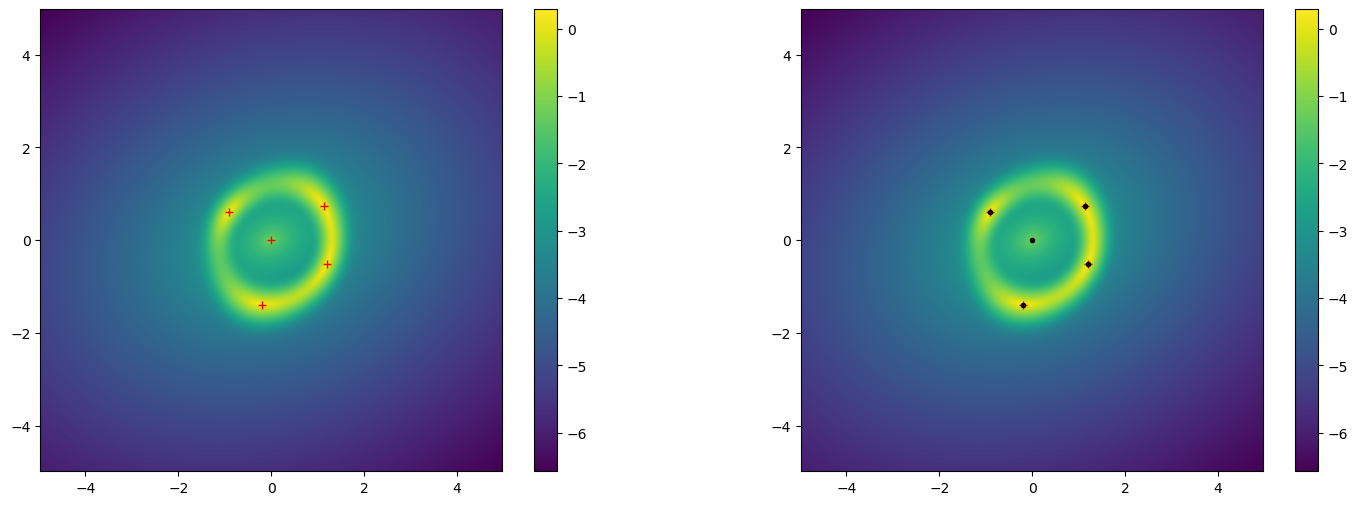

In [75]:
fig,ax = plt.subplots(1,2,figsize=(18,6))
ax_raytr = ax[0].imshow(np.log10(flux_lens+flux_source_singlens)-4,origin='lower',extent=(xmin_center,xmax_center,ymin_center,ymax_center))
ax_lenstro = ax[1].imshow(np.log10(flux_lens+flux_source_lenstro)-4,origin='lower',extent=(xmin_center,xmax_center,ymin_center,ymax_center))
ax[0].plot(xroot1_tmp_arcsec, xroot2_tmp_arcsec,'r+')
ax[1].plot(x_image, y_image, 'r+')
ax[1].plot(xroot1_tmp_arcsec, xroot2_tmp_arcsec,'k.')

fig.colorbar(ax_raytr,ax=ax[0])
fig.colorbar(ax_lenstro,ax=ax[1])

In [76]:
kappa_all_center = dataMY_all['kappa'].T
l_x_all_center   = dataMY_all['xf1']*3600
l_y_all_center   = dataMY_all['xf2']*3600
s_x_all_center   = dataMY_all['yf1']*3600
s_y_all_center   = dataMY_all['yf2']*3600
mua_all_center   = dataMY_all['mua'].T

In [77]:
xmin_all_center = np.min(l_x_all_center[:,0])
xmax_all_center = np.max(l_x_all_center[:,0])
ymin_all_center = np.min(l_y_all_center[0,:])
ymax_all_center = np.max(l_y_all_center[0,:])
print(xmin_all_center,xmax_all_center,ymin_all_center,ymax_all_center)

-4.9750000000000005 4.9750000000000005 -4.9750000000000005 4.9750000000000005


(-4.5, 4.5)

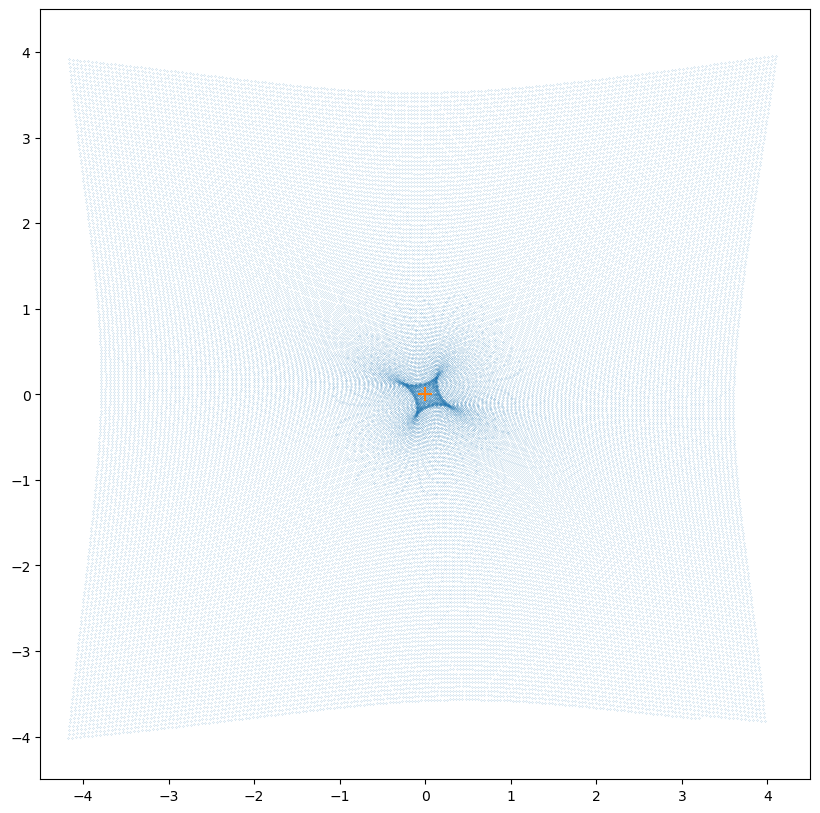

In [78]:
plt.figure(figsize=(10,10))
# s_x = dataMY_all['yf1'][mid-size_center:mid+size_center,mid-size_center:mid+size_center]
# s_y = dataMY_all['yf2'][mid-size_center:mid+size_center,mid-size_center:mid+size_center] 
plt.scatter(s_x_all_center, s_y_all_center,s=0.05, marker='.')
plt.scatter(0,\
            0, s=100, marker='+')
plt.gca().set_aspect("equal")
plt.xlim(-4.5,4.5)
plt.ylim(-4.5,4.5)

In [79]:
ra_arcsec, dec_arcsec = center_ra*3600, center_dec*3600
# import the LightModel class #
from lenstronomy.LightModel.light_model import LightModel
# set up the list of light models to be used #
source_light_model_list = ['SERSIC_ELLIPSE']
lightModel_source = LightModel(light_model_list=source_light_model_list)
# define the parameters #
kwargs_light_source = [{'amp': 4000, 'R_sersic': 0.1, 'n_sersic': 1, 'e1': -0.1, 'e2': 0.1, 'center_x': source_x, 'center_y': source_y}]

In [80]:
# evaluate surface brightness at a specific position #
flux_all = lightModel_source.surface_brightness(x=s_x_all_center, y=s_y_all_center, kwargs_list=kwargs_light_source).T

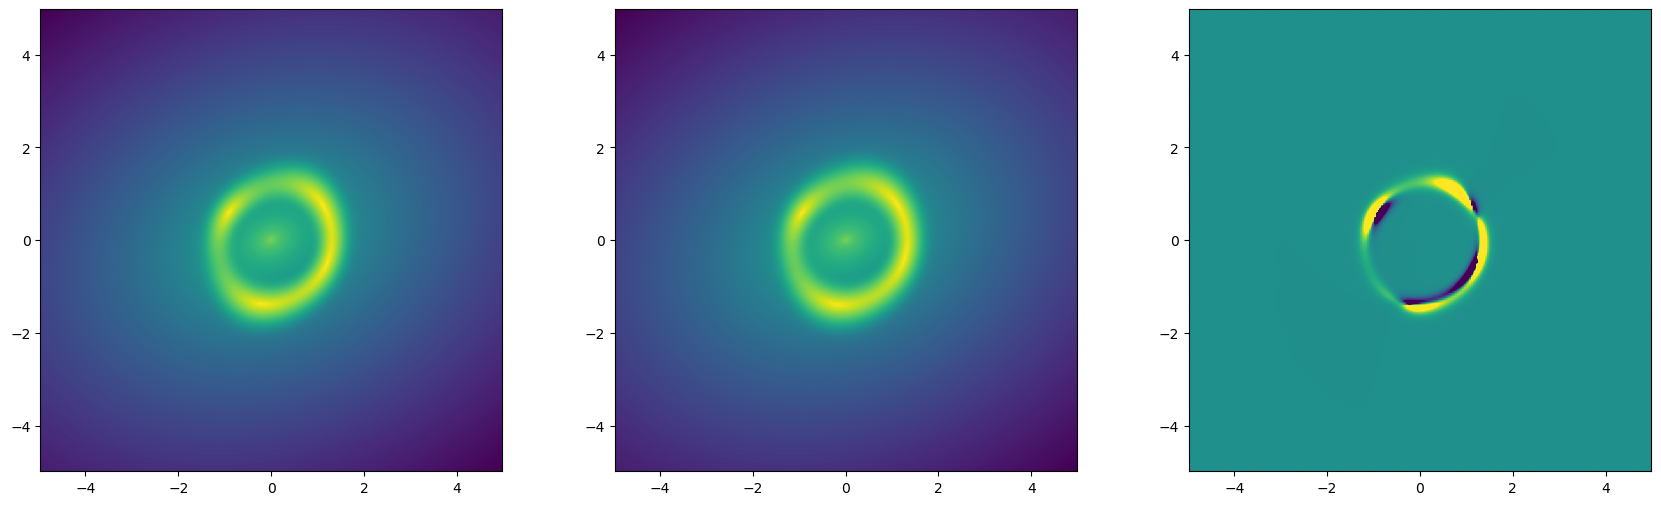

In [81]:
fig_image,ax_image=plt.subplots(1,3,figsize=(21,6))
ax_image[0].imshow(np.log10(flux_lens+flux_source_singlens),origin='lower',extent=(xmin_center,xmax_center,ymin_center,ymax_center))
ax_image[1].imshow(np.log10(flux_all+flux_lens),origin='lower',extent=(xmin_center,xmax_center,ymin_center,ymax_center))
ax_image[2].imshow(flux_all-flux_source_singlens,origin='lower',extent=(xmin_center,xmax_center,ymin_center,ymax_center),\
            vmin = np.min(flux_all-flux_source_singlens)/10,vmax = -np.min(flux_all-flux_source_singlens)/10)
# fig_image.colorbar()

In [82]:
xroot1_all_arcsec, xroot2_all_arcsec = \
                    cf.call_mapping_triangles([source_x, source_y],\
                                               l_x_all_center,l_y_all_center, \
                                               s_x_all_center,s_y_all_center)

In [83]:
# keep 3 digits
# xroot1_all_arcsec = np.round(xroot1_all_arcsec-np.median(xroot1_all_arcsec),3)
# xroot2_all_arcsec = np.round(xroot2_all_arcsec-np.median(xroot2_all_arcsec),3)

xroot1_all_arcsec = np.round(xroot1_all_arcsec,3)
xroot2_all_arcsec = np.round(xroot2_all_arcsec,3)


sourceID_all_x = np.round(xroot1_all_arcsec/0.05).astype(int)+int(numPix/2)
sourceID_all_y = np.round(xroot2_all_arcsec/0.05).astype(int)+int(numPix/2)

mua_image_los = mua_los_center[sourceID_all_y,sourceID_all_x]

xroot1_all_arcsec = xroot1_all_arcsec[sourceID_all_y != numPix/2]
xroot2_all_arcsec = xroot2_all_arcsec[sourceID_all_y != numPix/2]
mua_image_los = mua_image_los[sourceID_all_y != numPix/2]
mua_image_sl  = lens_model_class.magnification(xroot1_all_arcsec, xroot2_all_arcsec, kwargs=kwargs_lens)
mua_image_all = mua_image_los*mua_image_sl

print(sourceID_all_x,sourceID_all_y)
print(xroot1_all_arcsec, xroot2_all_arcsec)
print(mua_image_los)
print(mua_image_sl)
print(mua_image_all)

[ 81  96 122 125 100] [112  72 116  92 100]
[-0.95  -0.192  1.096  1.266] [ 0.59  -1.399  0.783 -0.405]
[1.02935012 1.04168182 1.06792126 1.05528087]
[-2.64405481  4.8504566   6.2076182  -7.47101196]
[-2.72165814  5.05263248  6.62924745 -7.88401598]


In [84]:
print(x_image, y_image)
print(mag)

[-0.204  1.132  1.211 -0.907] [-1.388  0.739 -0.511  0.6  ]
[ 4.94056862  6.39472729 -6.09950663 -2.40795834]


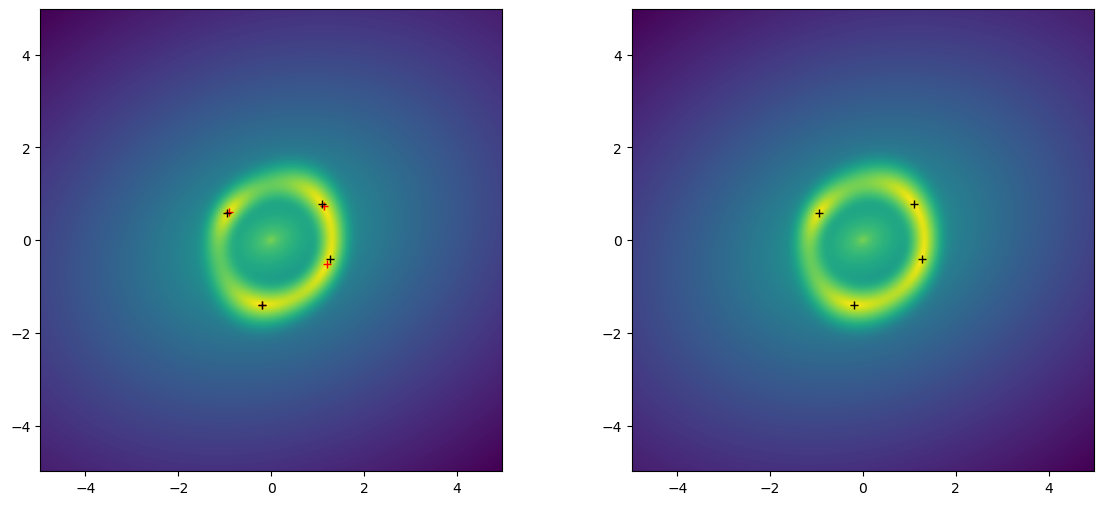

In [85]:
fig_image,ax_image=plt.subplots(1,2,figsize=(14,6))
ax_image[0].imshow(np.log10(flux_lens+flux_source_singlens),origin='lower',extent=(xmin_center,xmax_center,ymin_center,ymax_center))
ax_image[1].imshow(np.log10(flux_all+flux_lens),origin='lower',extent=(xmin_all_center,xmax_all_center,ymin_all_center,ymax_all_center))
ax_image[0].plot(x_image, y_image, 'r+')
ax_image[0].plot(xroot1_all_arcsec, xroot2_all_arcsec,'k+')
ax_image[1].plot(xroot1_all_arcsec, xroot2_all_arcsec,'k+')

In [86]:
np.savez('/huawei/osv1/linshijie_BNU/PAPER1/data/image_rays/case{:04}'.format(case)+'/image_data',flux_ML=flux_lens+flux_source_singlens,flux_WL=flux_lens+flux_all)

In [87]:
print(xroot1_all_arcsec,xroot2_all_arcsec,mua_image_all)
print(x_image,y_image,mag)
# print(xroot1_all_arcsec_sort,xroot2_all_arcsec_sort,mua_image_los_sort)
# print(x_image0,y_image0,mag0)

[-0.95  -0.192  1.096  1.266] [ 0.59  -1.399  0.783 -0.405] [-2.72165814  5.05263248  6.62924745 -7.88401598]
[-0.204  1.132  1.211 -0.907] [-1.388  0.739 -0.511  0.6  ] [ 4.94056862  6.39472729 -6.09950663 -2.40795834]


In [88]:
# save the x_image and y_image in one txt file
np.savez('/huawei/osv1/linshijie_BNU/PAPER1/data/image_rays/case{:04}'.format(case)+'/PointSources',\
         x_oml=x_image,y_oml=y_image,mag_oml=mag,\
         x_all=xroot1_all_arcsec,y_all=xroot2_all_arcsec, mag_pert=mua_image_los, mag_all=mua_image_all)
# np.savetxt('/huawei/osv1/linshijie_BNU/simu_data/image_rays/case{:04}'.format(case)+'/x_image.txt',x_image)